In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from scipy.signal import find_peaks
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import math
from src.feature_engineering import * 
from src.data_preprocessing import * 

In [2]:
df = pd.read_csv('../datasets/processed/train.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6127 entries, 0 to 6126
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   timestamp                    6127 non-null   object 
 1   temperature                  6127 non-null   float64
 2   humidity                     6127 non-null   float64
 3   surface_radiation            6127 non-null   float64
 4   upper_atmospheric_radiation  6127 non-null   float64
 5   hour                         6127 non-null   int64  
 6   month                        6127 non-null   int64  
 7   air_density                  6127 non-null   float64
 8   wind_velocity                6127 non-null   float64
 9   output_hybrid                6127 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 478.8+ KB


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

target_feature = 'output_hybrid'
feature_data = df[target_feature]

In [5]:
features = [
    'temperature', 
    'humidity', 
    'surface_radiation', 
    'upper_atmospheric_radiation',  
    'air_density', 
    'wind_velocity',  
    'output_hybrid'
]

In [6]:
spesific_lag = [6, 12, 24, 48, 72]

for col in features:
    print(f"ACF CORRELATION VALUE: {col.upper()}")
    
    acf_values_all = acf(df[col], nlags=72)
    
    for lag in spesific_lag:
        info = f"({lag} hours ago)"
        if lag >= 24:
            info = f"({int(lag/24)} days ago)"
            
        print(f"Lag {lag:2d} {info:12s} : {acf_values_all[lag]:.4f}")

ACF CORRELATION VALUE: TEMPERATURE
Lag  6 (6 hours ago) : 0.9267
Lag 12 (12 hours ago) : 0.8696
Lag 24 (1 days ago) : 0.9688
Lag 48 (2 days ago) : 0.9448
Lag 72 (3 days ago) : 0.9299
ACF CORRELATION VALUE: HUMIDITY
Lag  6 (6 hours ago) : 0.9863
Lag 12 (12 hours ago) : 0.9773
Lag 24 (1 days ago) : 0.9778
Lag 48 (2 days ago) : 0.9587
Lag 72 (3 days ago) : 0.9431
ACF CORRELATION VALUE: SURFACE_RADIATION
Lag  6 (6 hours ago) : -0.0285
Lag 12 (12 hours ago) : -0.5934
Lag 24 (1 days ago) : 0.9627
Lag 48 (2 days ago) : 0.9440
Lag 72 (3 days ago) : 0.9357
ACF CORRELATION VALUE: UPPER_ATMOSPHERIC_RADIATION
Lag  6 (6 hours ago) : 0.0206
Lag 12 (12 hours ago) : -0.6597
Lag 24 (1 days ago) : 0.9965
Lag 48 (2 days ago) : 0.9935
Lag 72 (3 days ago) : 0.9904
ACF CORRELATION VALUE: AIR_DENSITY
Lag  6 (6 hours ago) : 0.9676
Lag 12 (12 hours ago) : 0.9383
Lag 24 (1 days ago) : 0.9752
Lag 48 (2 days ago) : 0.9511
Lag 72 (3 days ago) : 0.9372
ACF CORRELATION VALUE: WIND_VELOCITY
Lag  6 (6 hours ago) : 0.5

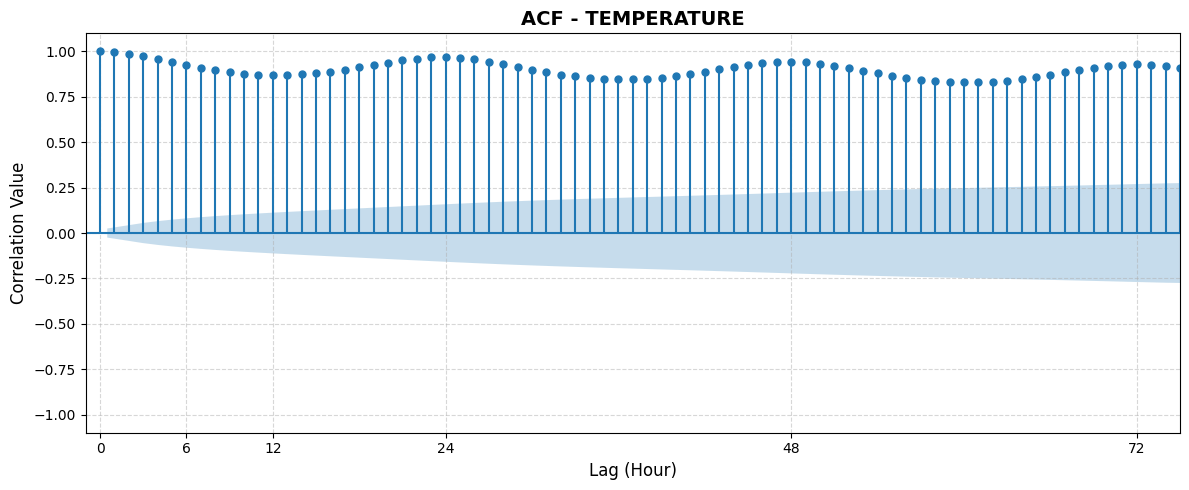

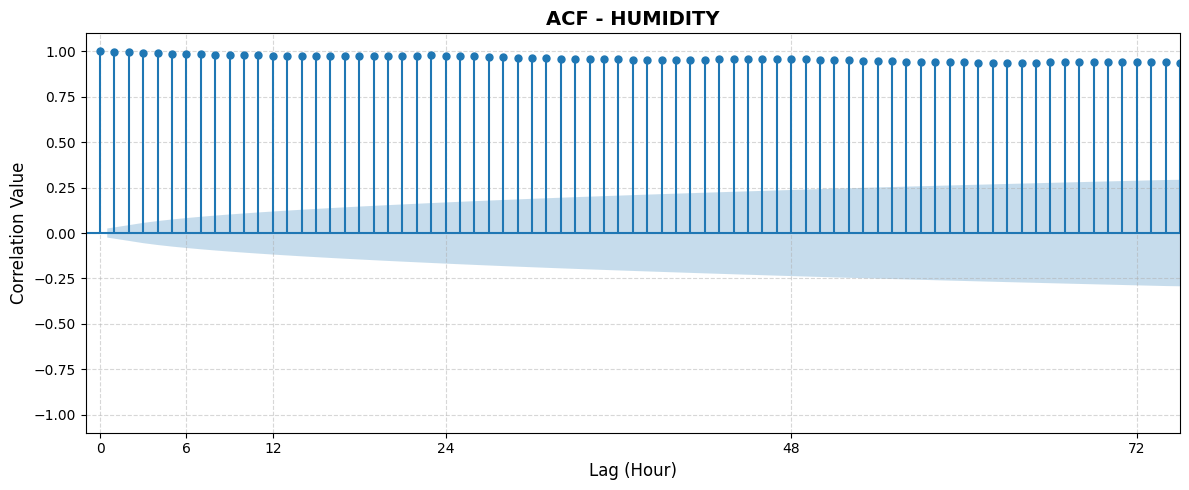

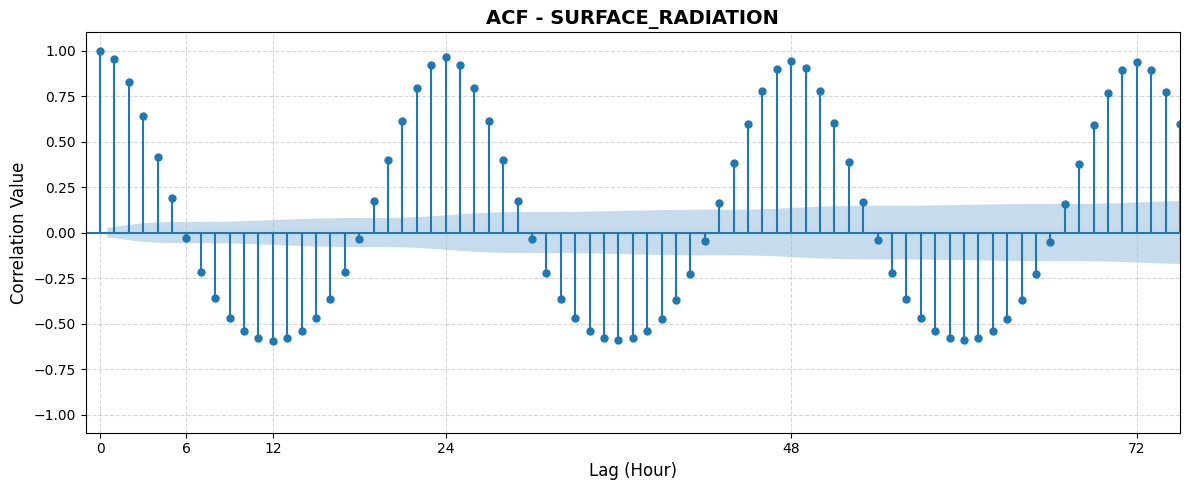

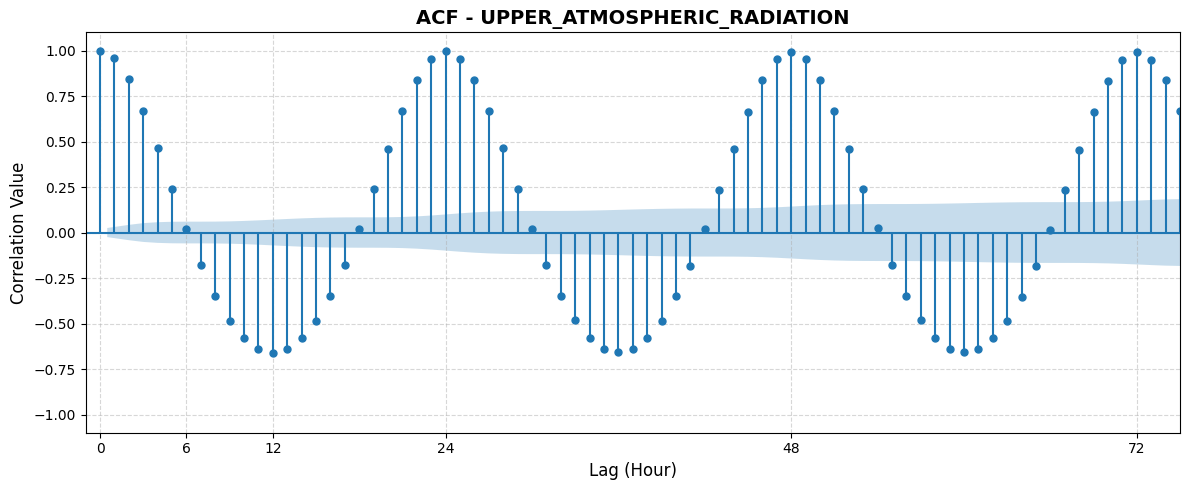

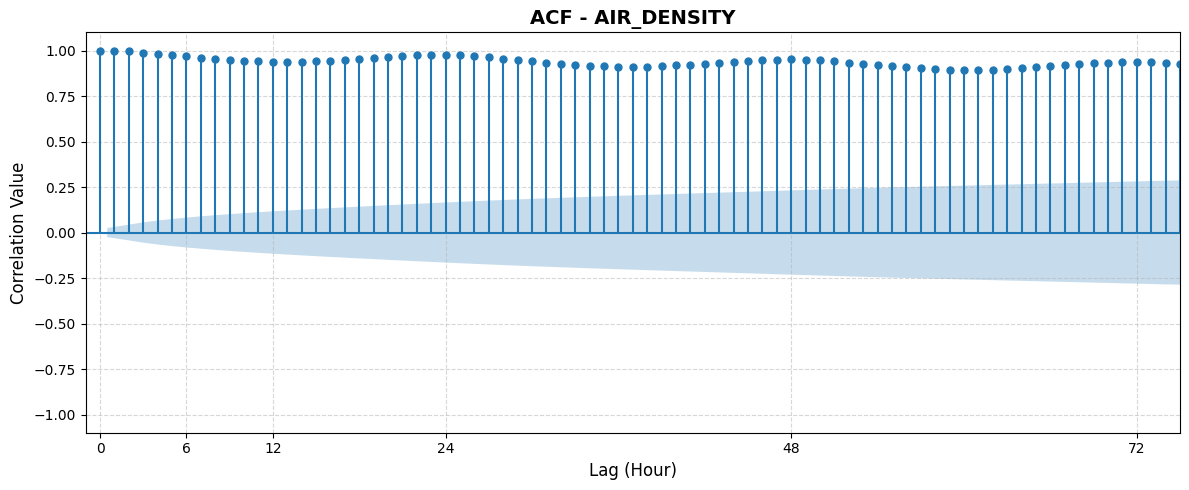

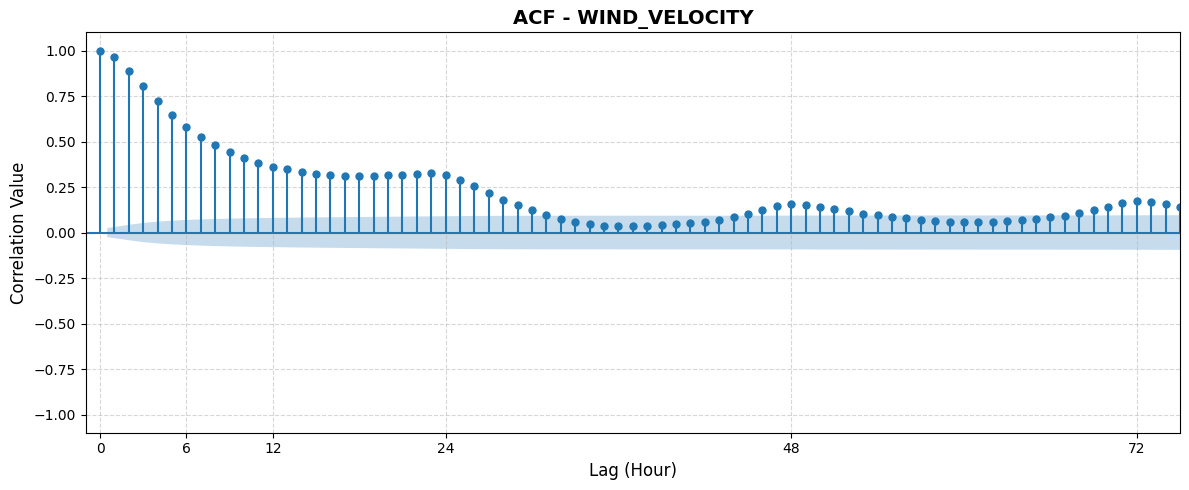

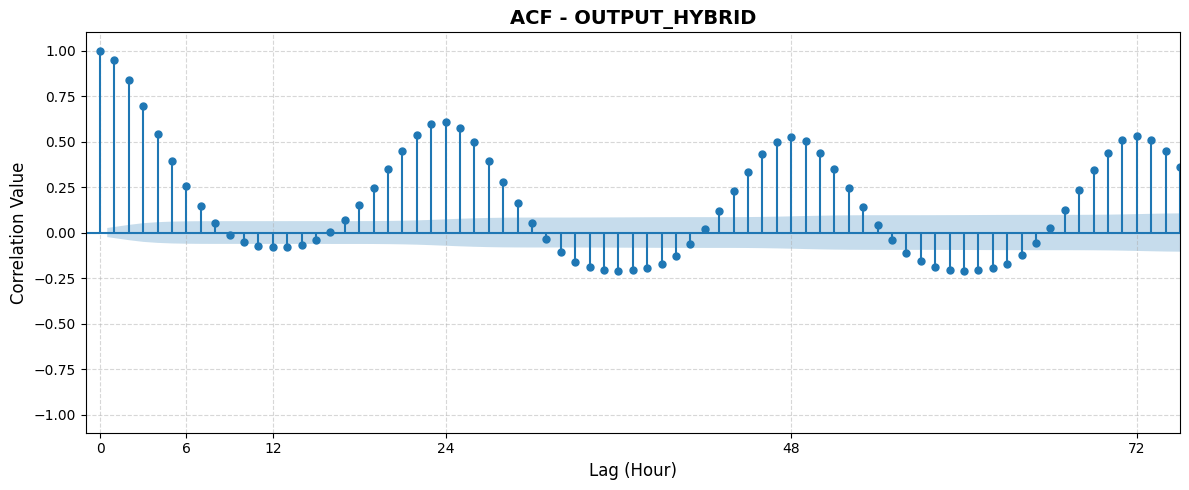

In [7]:
for fitur_target in features:
    
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_acf(df[fitur_target].dropna(), lags=75, alpha=0.05, ax=ax) 
    
    plt.title(f'ACF - {fitur_target.upper()}', fontsize=14, fontweight='bold')
    plt.xlabel('Lag (Hour)', fontsize=12)
    plt.ylabel('Correlation Value', fontsize=12)
    
    plt.ylim(-1.1, 1.1)
    plt.xlim(-1, 75)
    plt.xticks([0] + spesific_lag) 
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

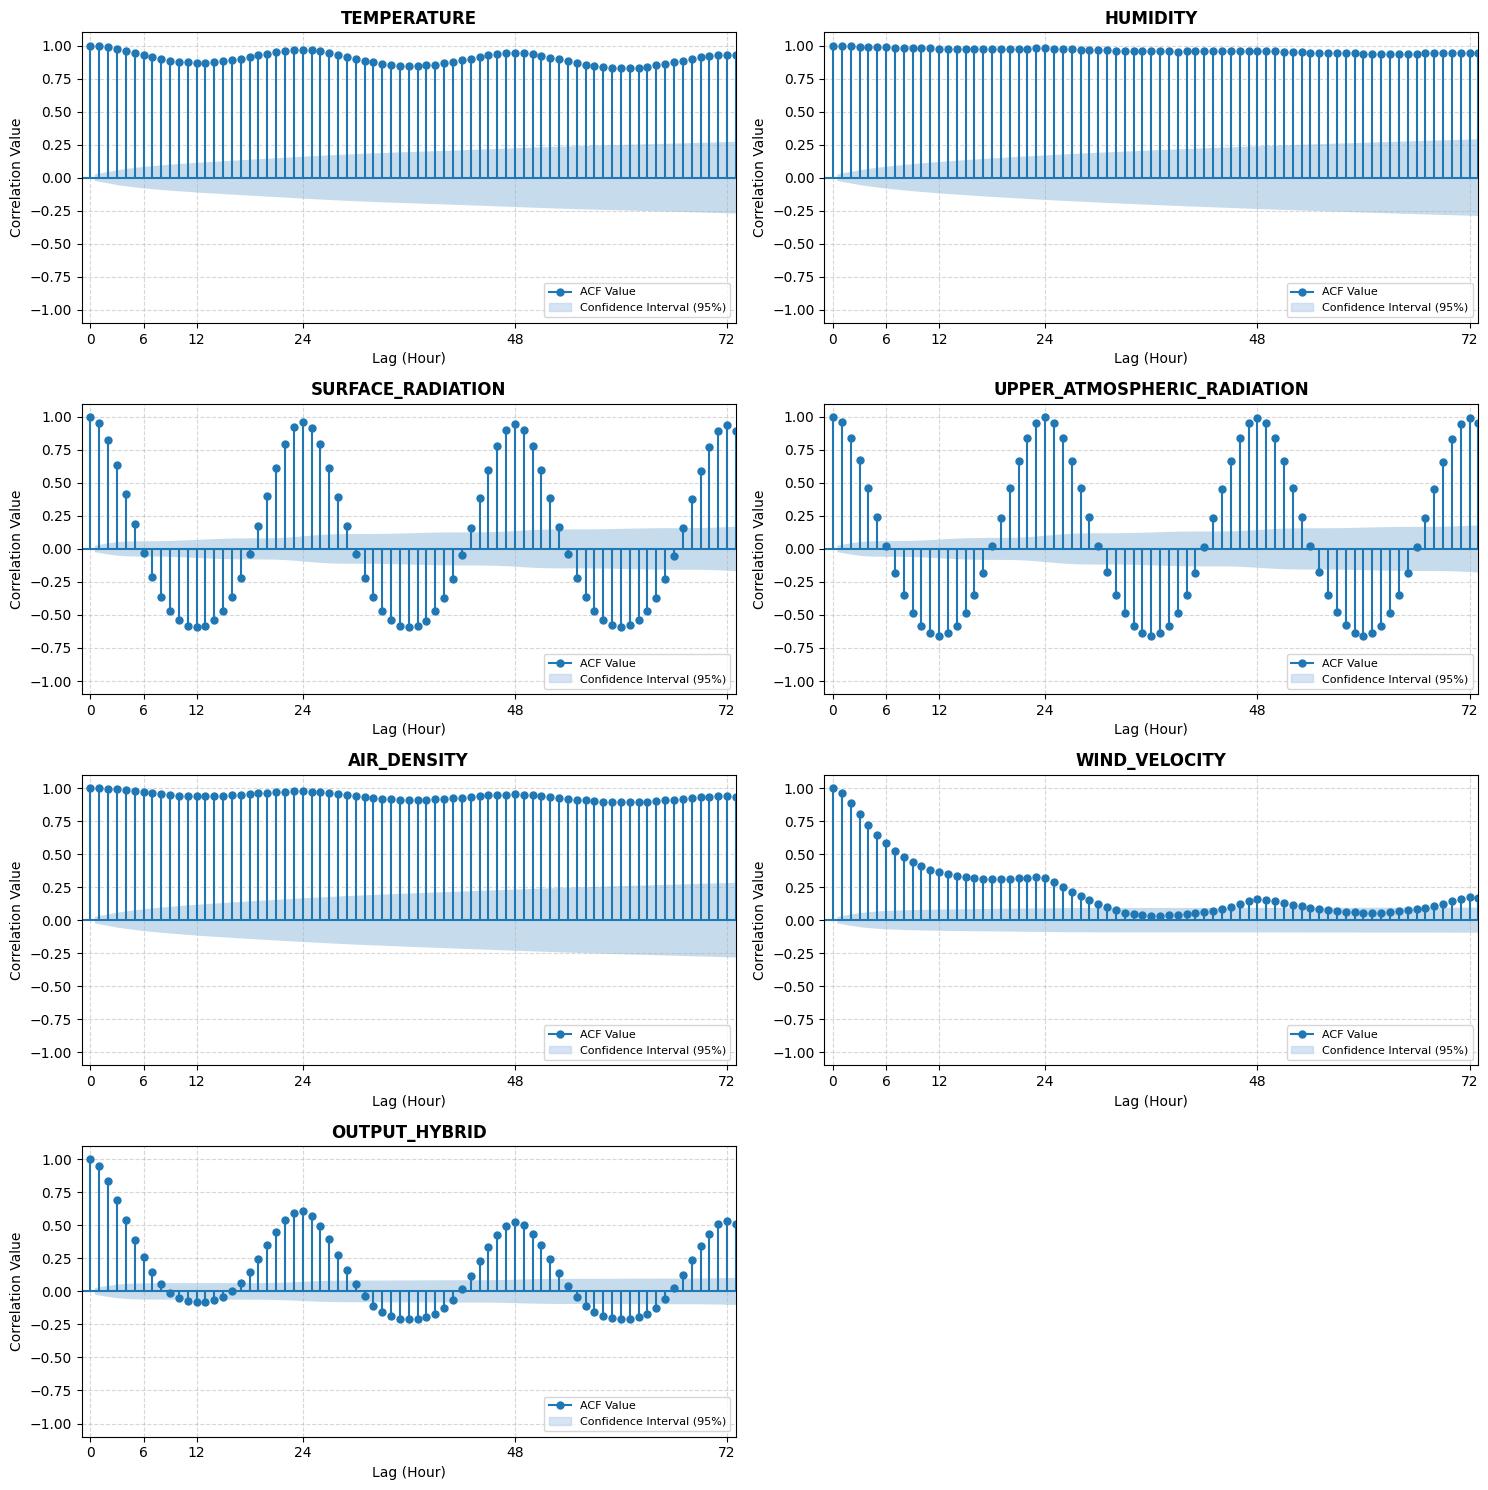

In [8]:
n_features = len(features)
cols = 2
rows = math.ceil(n_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
axes = axes.flatten() 

for i, fitur_target in enumerate(features):
    plot_acf(df[fitur_target].dropna(), lags=75, alpha=0.05, ax=axes[i])
    
    axes[i].set_title(f'{fitur_target.upper()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Lag (Hour)', fontsize=10)
    axes[i].set_ylabel('Correlation Value', fontsize=10)
    axes[i].set_ylim(-1.1, 1.1)
    axes[i].set_xlim(-1, 73)
    axes[i].set_xticks([0] + spesific_lag)
    axes[i].grid(True, linestyle='--', alpha=0.5)

    blue_patch = mpatches.Patch(color='#bcd2ee', alpha=0.6, label='Confidence Interval (95%)')
    acf_marker = mlines.Line2D([], [], color='#1f77b4', marker='o', linestyle='-', 
                               markersize=5, label='ACF Value')
    axes[i].legend(handles=[acf_marker, blue_patch], loc='lower right', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

=== HIGHLIGHT FEATURE: TEMPERATURE ===
Upper Peaks (> 0.5)        : [np.int64(24), np.int64(48), np.int64(72)]
Lower Peaks (< -0.5)      : []
Label Ticks Sumbu X        : [1, np.int64(24), np.int64(48), np.int64(72)]

=== HIGHLIGHT FEATURE: HUMIDITY ===
Upper Peaks (> 0.5)        : [np.int64(23), np.int64(48), np.int64(72)]
Lower Peaks (< -0.5)      : []
Label Ticks Sumbu X        : [1, np.int64(23), np.int64(48), np.int64(72)]

=== HIGHLIGHT FEATURE: SURFACE_RADIATION ===
Upper Peaks (> 0.5)        : [np.int64(24), np.int64(48), np.int64(72)]
Lower Peaks (< -0.5)      : [np.int64(12), np.int64(36), np.int64(60)]
Label Ticks Sumbu X        : [1, np.int64(12), np.int64(24), np.int64(36), np.int64(48), np.int64(60), np.int64(72)]

=== HIGHLIGHT FEATURE: UPPER_ATMOSPHERIC_RADIATION ===
Upper Peaks (> 0.5)        : [np.int64(24), np.int64(48), np.int64(72)]
Lower Peaks (< -0.5)      : [np.int64(12), np.int64(36), np.int64(60)]
Label Ticks Sumbu X        : [1, np.int64(12), np.int64(24), np

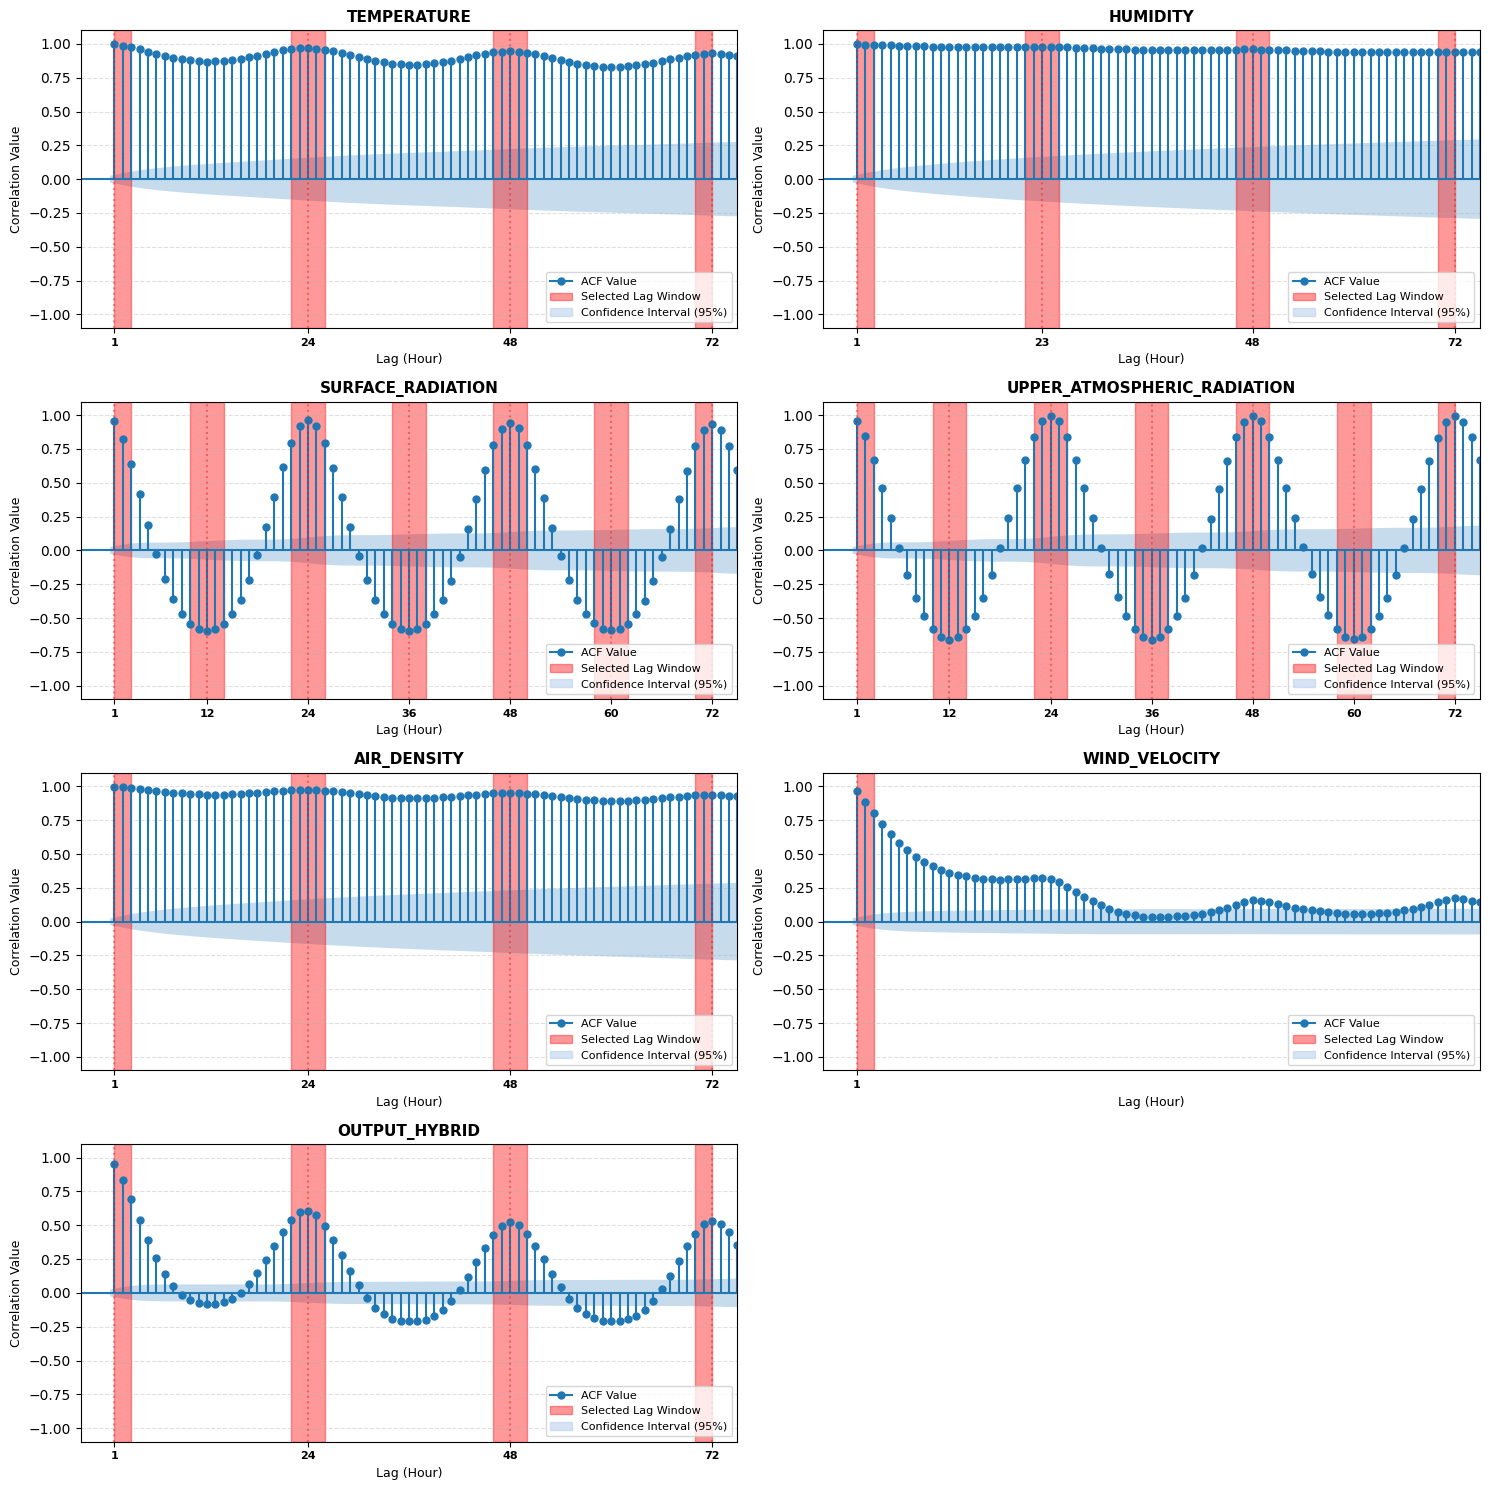

In [9]:
spesific_lag = list(range(1, 76))

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 15))
axes_flat = axes.flatten()

for i, target_feature in enumerate(features):
    ax = axes_flat[i] 
    
    data_bersih = df[target_feature].dropna()
    acf_value_all = acf(data_bersih, nlags=75)

    upper_peak, _ = find_peaks(acf_value_all, height=0.5)
    lower_peak, _ = find_peaks(-acf_value_all, height=0.5)

    extreme_point = list(upper_peak) + list(lower_peak)
    
    if 1 not in extreme_point: 
        extreme_point.append(1)

    lag_penting = sorted(list(set([1] + extreme_point)))
    lag_penting = [lag for lag in lag_penting if lag != 0]

    plot_acf(data_bersih, lags=spesific_lag, alpha=0.05, ax=ax)

    ax.axvspan(1, 3, color='red', alpha=0.4, label='Selected lag')

    for center in extreme_point:
        if center < 5: 
            continue
            
        nilai_korelasi_center = acf_value_all[center]
        
        if nilai_korelasi_center >= 0.5 or nilai_korelasi_center < -0.5:
            left_margin = center - 2
            right_margin = min(center + 2, 72)
            ax.axvspan(left_margin, right_margin, color='red', alpha=0.4)
    
    ax.set_xlim(-3, 75)   
    ax.set_ylim(-1.1, 1.1) 
    ax.set_xticks(lag_penting)
    ax.set_xticklabels(lag_penting, fontsize=8, fontweight='bold', rotation=0)

    for lag in lag_penting:
        ax.axvline(x=lag, color='red', linestyle=':', alpha=0.4)

    ax.set_title(f'{target_feature.upper()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Lag (Hour)', fontsize=9)
    ax.set_ylabel('Correlation Value', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=8)
    
    red_patch = mpatches.Patch(color='red', alpha=0.4, label='Selected Lag Window')
    blue_patch = mpatches.Patch(color='#bcd2ee', alpha=0.6, label='Confidence Interval (95%)')
    
    acf_marker = mlines.Line2D([], [], color='#1f77b4', marker='o', linestyle='-', 
                               markersize=5, label='ACF Value')
    
    ax.legend(handles=[acf_marker, red_patch, blue_patch], loc='lower right', fontsize=8)
    
    print(f"=== HIGHLIGHT FEATURE: {target_feature.upper()} ===")
    print(f"Upper Peaks (> 0.5)        : {list(upper_peak)}")
    print(f"Lower Peaks (< -0.5)      : {list(lower_peak)}")
    print(f"Label Ticks Sumbu X        : {lag_penting}\n")

for j in range(len(features), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

Chosen Lag Anchor Each Feature 
- temperature = 1, 24, 48, 72
- humidity = 1, 23, 47, 72 
- surface_radiation = 1, 12, 24, 36, 48, 60, 72 
- upper_atmospheric_radiation = 1, 12, 24, 36, 48, 60, 72 
- air_density = 1, 23, 47, 72 
- wind_velocity = 1
- output_hybrid = 1, 24, 48, 72


### Final Lag Extraction 

- temperature: 
    - 1, 2, 3, 22, 23, 24, 25, 26, 46, 47, 48, 49, 50, 70, 71, 72

- humidity: 
    - 1, 2, 3, 21, 22, 23, 24, 25, 45, 46, 47, 48, 49, 70, 71, 72

- surface_radiation: 
    - 1, 2, 3, 10, 11, 12, 13, 14, 22, 23, 24, 25, 26, 34, 35, 36, 37, 38, 46, 47, 48, 49, 50, 58, 59, 60, 61, 62, 70, 71, 72

- upper_atmospheric_radiation: 
    - 1, 2, 3, 10, 11, 12, 13, 14, 22, 23, 24, 25, 26, 34, 35, 36, 37, 38, 46, 47, 48, 49, 50, 58, 59, 60, 61, 62, 70, 71, 72

- air_density: 
    - 1, 2, 3, 21, 22, 23, 24, 25, 45, 46, 47, 48, 49, 70, 71, 72

- wind_velocity: 
    - 1, 2, 3

- output_hybrid: 
    - 1, 2, 3, 22, 23, 24, 25, 26, 46, 47, 48, 49, 50, 70, 71, 72


In [10]:
spesific_mapping_lag = {
    'temperature': [1, 2, 3, 22, 23, 24, 25, 26, 46, 47, 48, 49, 50, 70, 71, 72],
    'humidity': [1, 2, 3, 21, 22, 23, 24, 25, 45, 46, 47, 48, 49, 70, 71, 72],
    'surface_radiation': [1, 2, 3, 10, 11, 12, 13, 14, 22, 23, 24, 25, 26, 34, 35, 36, 37, 38, 46, 47, 48, 49, 50, 58, 59, 60, 61, 62, 70, 71, 72],
    'upper_atmospheric_radiation': [1, 2, 3, 10, 11, 12, 13, 14, 22, 23, 24, 25, 26, 34, 35, 36, 37, 38, 46, 47, 48, 49, 50, 58, 59, 60, 61, 62, 70, 71, 72],
    'air_density': [1, 2, 3, 21, 22, 23, 24, 25, 45, 46, 47, 48, 49, 70, 71, 72],
    'wind_velocity': [1, 2, 3], 
    'output_hybrid': [1, 2, 3, 22, 23, 24, 25, 26, 46, 47, 48, 49, 50, 70, 71, 72], 
}

train_df = load_dataset("../datasets/processed/train.csv")
eval_df = load_dataset("../datasets/processed/eval.csv")
test_df = load_dataset("../datasets/processed/test.csv")
train_combine_df = load_dataset("../datasets/processed/train_combine.csv")

train_clean = create_lag_dataset(
    df=train_df,
    lag_mapping=spesific_mapping_lag,
    drop_columns=['output_pv','output_wind']
)

eval_extended = pd.concat([train_df.iloc[-72:], eval_df], axis=0)
eval_clean = create_lag_dataset(
    df=eval_extended,
    lag_mapping=spesific_mapping_lag,
    drop_columns=['output_pv', 'output_wind']
)

test_extended = pd.concat([eval_df.iloc[-72:], test_df], axis=0)
test_clean = create_lag_dataset(
    df=test_extended,
    lag_mapping=spesific_mapping_lag,
    drop_columns=['output_pv', 'output_wind']
)

train_combine_clean = create_lag_dataset(
    df=train_combine_df, 
    lag_mapping=spesific_mapping_lag, 
    drop_columns=['output_pv', 'output_wind']
)

train_clean.to_csv('../datasets/processed/train_lag.csv', index=False)
eval_clean.to_csv('../datasets/processed/eval_lag.csv', index=False)
test_clean.to_csv('../datasets/processed/test_lag.csv', index=False)
train_combine_clean.to_csv('../datasets/processed/train_combine_lag.csv', index=False)

In [11]:
feature_summary(train_clean,"Train")
feature_summary(eval_clean,"Eval")
feature_summary(test_clean,"Test")
feature_summary(train_combine_clean, "Train Combine")


=== TRAIN ===
Rows                : 6055
Total Features      : 139
Original Features   : 10
Lag Features        : 129

=== EVAL ===
Rows                : 1313
Total Features      : 139
Original Features   : 10
Lag Features        : 129

=== TEST ===
Rows                : 1313
Total Features      : 139
Original Features   : 10
Lag Features        : 129

=== TRAIN COMBINE ===
Rows                : 7368
Total Features      : 139
Original Features   : 10
Lag Features        : 129


In [12]:
feature_summary(train_df, "Train Raw")
feature_summary(train_clean, "Train Cleaned")

feature_summary(eval_df, "Eval Raw")
feature_summary(eval_clean, "Eval Cleaned") # must same total rows eval raw and eval cleaned


=== TRAIN RAW ===
Rows                : 6127
Total Features      : 10
Original Features   : 10
Lag Features        : 0

=== TRAIN CLEANED ===
Rows                : 6055
Total Features      : 139
Original Features   : 10
Lag Features        : 129

=== EVAL RAW ===
Rows                : 1313
Total Features      : 10
Original Features   : 10
Lag Features        : 0

=== EVAL CLEANED ===
Rows                : 1313
Total Features      : 139
Original Features   : 10
Lag Features        : 129


In [13]:
# 1. Ambil semua list kolom lag yang sesungguhnya terbuat di dataframe
lag_terbuat = [col for col in train_clean.columns if "_lag_" in col]

# 2. Bikin list lag yang seharusnya terbuat berdasarkan dictionary mapping
lag_seharusnya = []
for feature, lags in spesific_mapping_lag.items():
    for lag in lags:
        lag_seharusnya.append(f"{feature}_lag_{lag}")

# 3. Cari tahu mana 2 kolom yang tidak match!
kolom_hilang = set(lag_seharusnya) - set(lag_terbuat)
print("Kolom lag yang hilang dari hasil generate:", kolom_hilang)

Kolom lag yang hilang dari hasil generate: set()
